### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path
BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/health_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/health_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [3]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [4]:
Health_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Healthcare Systems",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
Health_chunks.head(2)

,chunk_uid,url,date,title,topic_v0,chunk_text
0,0_0_0_0_0,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",0,"""A Gift To Humanity"": AlphaFold AI Predicts St..."
1,0_0_0_0_1,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",0,"That may sound like a lot overall, but it’s th..."


In [7]:
print(len(Health_chunks))

13116


### Bertopic

In [6]:
# ! pip install bertopic

In [37]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small" , device="cuda")

umap_model = UMAP(
    n_neighbors=50, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=20, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

# 100,20
hdbscan_model = HDBSCAN(
    min_cluster_size=100, # smaller min_cluster_size will -> more detailed topics
    min_samples=20, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
docs = Health_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [39]:
Health_topics = topic_model.get_topic_info()
Health_chunks_topics = Health_chunks.assign( topic=topics,  probability=probs)

In [45]:
show_full(Health_topics[["Topic", 'Representation',"Count"]])

,Topic,Representation,Count
0,-1,"[gray media, aidoc, healthcare industry, sepsis, coding, mayo clinic, nvidia, healthcare organizations, google cloud, forward-looking]",5475
1,0,"[intelligence drug, discovery market, insilico, genomics, molecules, candidates, lilly, molecule, discovery development, recursion]",1328
2,1,"[lunit, tumor, mammograms, mammography, cancer detection, digital pathology, immune, cancer diagnostics, tumors, immunotherapy]",1305
3,2,"[chatbot, gpt-, exam, chatgpt health, medical licensing, licensing, med-palm, usmle, messages, medical education]",716
4,3,"[therapist, therapists, chatbot, emotional, depression, wysa, jacobson, adhd, health support, ali]",556
5,4,"[protein, proteins, alphafold, deepmind, sequences, amino, enzymes, mutations, sequence, protein structures]",532
6,5,"[ecg, heart failure, cardiovascular disease, coronary, heart attack, atrial, heart attacks, fibrillation, atrial fibrillation, cardiology]",394
7,6,"[healthcare market, market research, cagr, market size, usd, usd billion, market growth, forecast period, market report, remote patient]",331
8,7,"[biases, racial, biased, black patients, white patients, fairness, racial bias, data privacy, healthcare industry, medical images]",293
9,8,"[terarecon, philips, rad, sirona, concertai, eureka, radiologist, eureka clinical, omni, pacs]",287


In [41]:
Health_topics.to_csv(f"{DATA_DIR}/Health_specific/Health_topics.csv", index=False)
Health_chunks_topics.to_parquet(f"{DATA_DIR}/Health_specific/Health_chunks_topics.parquet", index=False)

### Filter AI Impact related content

In [42]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [47]:
system_msg = """
You are an expert healthcare industry analyst and topic validation assistant.

Your task is to determine whether a BERTopic topic cluster represents a
meaningful healthcare-related topic or meaningless/irrelevant clustered text.

All topics already contain AI-related terms, so AI presence alone should NOT
be used as evidence. Your task is to judge whether the topic meaningfully
relates to the healthcare industry.

You must classify each topic into EXACTLY ONE of the following 2 categories,
based on the combined evidence from:

1. topic keyword representation
2. representative documents

### The 2 Categories

1. "Meaningful_Healthcare_Topic"

Definition:
The topic represents a coherent discussion related to the healthcare industry,
medical research, healthcare services, public health, pharmaceuticals,
biotechnology, hospitals, clinical care, medical technology, or health systems.

These topics should show a clear healthcare-related theme.


2. "Noise_or_Irrelevant"

Definition:
The topic cluster does NOT represent a meaningful healthcare topic.

This includes:

- website navigation fragments
- advertisement blocks
- cookie/privacy notices
- subscription prompts
- duplicated headers or metadata
- social sharing buttons
- mixed unrelated snippets
- webpage UI/button fragments
- truncated crawl artifacts
- meaningless or incoherent word clusters
- topics that clearly belong to unrelated industries
  (e.g., finance, sports, entertainment, politics) without healthcare relevance

If the representative documents do not form a clear healthcare-related theme,
or appear to be web-crawl artifacts or unrelated content,
choose this category.

### Decision Rules

- Return EXACTLY ONE category.
- Use BOTH topic Representation and Representative_Docs.
- Focus on whether the topic forms a coherent healthcare-related theme.
- If the topic clearly relates to healthcare → "Meaningful_Healthcare_Topic".
- If the topic appears noisy, fragmented, or unrelated to healthcare → "Noise_or_Irrelevant".


### Output Requirements

Return valid JSON only with the following fields:

- "category": one of the 2 category names exactly
- "relevant_keywords": a short list of the most informative keywords/phrases supporting the choice
- "reasoning": brief explanation of why the topic belongs to that category
- "reviewing": brief review of what the representative documents are mainly about and whether they support the classification

Be conservative: if the topic lacks a clear healthcare theme, prefer "Noise_or_Irrelevant".
"""

# =========================================================
# 2. User prompt template
# =========================================================
topic_classification_user_template = """
Here is one BERTopic topic from the healthcare domain.

Topic ID:
{Topic}

Topic Representation:
{Representation}

Representative documents:
{Representative_Docs}

Please classify this topic into exactly one of the 2 categories:

- Meaningful_Healthcare_Topic
- Noise_or_Irrelevant

Use the topic representation as the primary topic signal and use representative documents
to confirm the main semantic focus.

Return JSON only.
"""

# =========================================================
# 3. JSON schema
# =========================================================
topic_classification_schema = {
    "type": "object",
    "properties": {
        "category": {
            "type": "string",
            "enum": [
                "Meaningful_Healthcare_Topic",
                "Noise_or_Irrelevant"
            ]
        },
        "relevant_keywords": {
            "type": "array",
            "items": {"type": "string"}
        },
        "reasoning": {
            "type": "string"
        },
        "reviewing": {
            "type": "string"
        }
    },
    "required": ["category", "relevant_keywords", "reasoning", "reviewing"],
    "additionalProperties": False
}

In [48]:
@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)


# =========================================================
# 5. Helper functions
# =========================================================
VALID_CATEGORIES = {
    "Meaningful_Healthcare_Topic",
    "Noise_or_Irrelevant"
}

def safe_str(x):
    if x is None:
        return ""
    return str(x)

def format_representation(x, max_chars=2500):
    text = safe_str(x).strip()
    if not text:
        return "[No topic representation provided]"
    return text[:max_chars]

def format_representative_docs(x, max_chars=12000):
    text = safe_str(x).strip()
    if not text:
        return "[No representative text provided]"
    return text[:max_chars]

def normalize_result(result):
    fallback = {
        "category": "Noise_or_Irrelevant",
        "relevant_keywords": [],
        "reasoning": "The topic does not show a clear and coherent healthcare-related theme.",
        "reviewing": "Representative text is unclear, mixed, noisy, or not meaningfully related to healthcare."
    }

    if not isinstance(result, dict):
        return fallback

    category = result.get("category")
    relevant_keywords = result.get("relevant_keywords", [])
    reasoning = result.get("reasoning", "")
    reviewing = result.get("reviewing", "")

    if category not in VALID_CATEGORIES:
        return fallback

    if not isinstance(relevant_keywords, list):
        relevant_keywords = []

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    if not isinstance(reviewing, str) or not reviewing.strip():
        reviewing = fallback["reviewing"]

    normalized = {
        "category": category,
        "relevant_keywords": [str(k) for k in relevant_keywords],
        "reasoning": reasoning.strip(),
        "reviewing": reviewing.strip()
    }

    try:
        validate(instance=normalized, schema=topic_classification_schema)
        return normalized
    except ValidationError:
        return fallback

In [49]:
# 6. Batch run
# =========================================================
answers = []

for idx, row in Health_topics.iterrows():
    user_msg = topic_classification_user_template.format(
        Topic=safe_str(row.get("Topic", "")),
        Representation=format_representation(row.get("Representation", ""), max_chars=2500),
        Representative_Docs=format_representative_docs(row.get("Representative_Docs", ""), max_chars=12000)
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)

        if "Insufficient Balance" in err_msg or "402" in err_msg:
            print(f"Stopped at row {idx}: insufficient API balance.")
            break

        result = {
            "category": None,
            "relevant_keywords": None,
            "reasoning": None,
            "reviewing": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    answers.append(result)

answers_df = pd.DataFrame(answers)

Health_topics_out = pd.concat(
    [Health_topics.iloc[:len(answers)].reset_index(drop=True),
     answers_df.reset_index(drop=True)],
    axis=1
)

Health_topics_out.head()

,Topic,Count,Name,Representation,Representative_Docs,category,relevant_keywords,reasoning,reviewing,api_status
0,-1,5475,-1_gray media_aidoc_healthcare industry_sepsis,"[gray media, aidoc, healthcare industry, sepsi...",[Andor Health announces integration with Point...,Meaningful_Healthcare_Topic,"[healthcare industry, sepsis, mayo clinic, hea...",The topic represents a coherent discussion abo...,The representative documents are press release...,success
1,0,1328,0_intelligence drug_discovery market_insilico_...,"[intelligence drug, discovery market, insilico...",[PESTLE Analysis4.2.5. Artificial Intelligence...,Meaningful_Healthcare_Topic,"[intelligence drug, discovery market, genomics...",The topic represents a coherent discussion abo...,The representative documents consistently disc...,success
2,1,1305,1_lunit_tumor_mammograms_mammography,"[lunit, tumor, mammograms, mammography, cancer...","[Study Validates Lunit AI as a Game-Changer, P...",Meaningful_Healthcare_Topic,"[tumor, mammograms, mammography, cancer detect...",The topic represents a coherent healthcare the...,All three representative documents discuss Lun...,success
3,2,716,2_chatbot_gpt-_exam_chatgpt health,"[chatbot, gpt-, exam, chatgpt health, medical ...",[ChatGPT nearly passes radiology board exam - ...,Meaningful_Healthcare_Topic,"[medical licensing, USMLE, medical education, ...",The topic represents a coherent discussion abo...,The representative documents consistently disc...,success
4,3,556,3_therapist_therapists_chatbot_emotional,"[therapist, therapists, chatbot, emotional, de...",[The (artificial intelligence) therapist can s...,Meaningful_Healthcare_Topic,"[therapist, depression, mental health, clinica...",The topic represents a coherent discussion abo...,The representative documents are news articles...,success


In [51]:
category_topics = Health_topics_out.groupby('category')['Topic'].apply(list).to_dict()
print(category_topics)

df_ai_impact = Health_chunks_topics[Health_chunks_topics['topic'].isin(category_topics['Meaningful_Healthcare_Topic'])]

print(f"\n# of df_ai_impact chunks: {len(df_ai_impact)}")

{'Meaningful_Healthcare_Topic': [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 19, 20], 'Noise_or_Irrelevant': [13, 18]}

# of df_ai_impact chunks: 12850


In [ ]:
df_ai_impact.to_parquet(f"{DATA_DIR}/Health_specific/health_meaningful_df_ai_impact.parquet", index=False)

### Sentiment Analysis on chunk level

##### 1. use LLM to generate 100 labels

In [58]:
df_ai_impact['topic'].value_counts()    

,count
topic,
-1,5475
0,1328
1,1305
2,716
3,556
4,532
5,394
6,331
7,293


In [ ]:
def topic_sample_n(topic_size):
    if topic_size >= 1000:
        return 80
    elif topic_size >= 500:
        return 35
    elif topic_size >= 200:
        return 20
    else:
        return 15

random_state = 38

df_ai_impact_sample = (
    df_ai_impact
    .groupby("topic", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), topic_sample_n(len(x))),
        random_state=random_state
    ))
    .reset_index(drop=True)
)

df_ai_impact_sample = df_ai_impact_sample[["chunk_uid", "topic", "chunk_text"]]
print(len(df_ai_impact_sample))
df_ai_impact_sample["topic"].value_counts()

590


/tmp/ipykernel_1558/4242844555.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


,count
topic,
-1,80
0,80
1,80
2,35
3,35
4,35
5,20
6,20
7,20


In [68]:
system_msg = """
You are an expert healthcare industry analyst.

Your task is to evaluate the directional impact of AI or AI-related developments
on the healthcare industry, healthcare organizations, healthcare companies,
clinical workflows, medical research, or patient care described in the text.

You must classify the impact into EXACTLY ONE of the following:

1. "positively"
Definition:
The text suggests that AI or related technologies are expected to benefit
healthcare organizations, healthcare companies, medical research, clinical practice,
healthcare operations, or patient outcomes.

This includes cases such as:
- improved diagnostic accuracy or decision support
- faster drug discovery or biomedical research
- more efficient hospital or clinic workflows
- cost reduction or productivity improvement
- better patient monitoring, triage, or care delivery
- improved access to care or service quality
- innovation, growth, competitive advantage, or new opportunities in healthcare

2. "negatively"
Definition:
The text suggests that AI or related technologies are expected to harm,
threaten, or create substantial downside risks for healthcare organizations,
healthcare workers, healthcare companies, or patients.

This includes cases such as:
- job displacement or workflow disruption
- safety concerns, medical errors, or harmful outcomes
- privacy risks, bias, unfairness, or ethical concerns
- regulatory barriers, liability exposure, or compliance risk
- increased operational burden, implementation failure, or financial pressure
- reduced trust, adoption problems, or structural threats to existing players

3. "hard-to-say"
Definition:
The text is mixed, uncertain, speculative, balanced, or mainly descriptive
without a clear dominant positive or negative direction.

Examples include:
- both benefits and risks are discussed without one clearly dominating
- the text is forward-looking but uncertain
- the text describes AI use in healthcare without clearly evaluating impact
- the content is factual or explanatory rather than directional

### Decision Rules

- Focus on the MAIN directional implication of the text.
- Evaluate impact specifically in a healthcare context.
- Consider effects on providers, hospitals, payers, pharma, biotech, medtech,
  clinicians, patients, healthcare operations, and medical research.
- Do not over-interpret isolated optimistic or pessimistic phrases.
- If both positive and negative effects are present without a clear dominant direction,
  choose "hard-to-say".
- If the text is mostly descriptive or factual without clear directional judgment,
  choose "hard-to-say".
- Ignore boilerplate, navigation fragments, ads, and irrelevant web residue.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly explain the main evidence for the label in the healthcare context.
"""

impact_user_template = """
Here is a text segment from the health domain:

{chunk_text}

Please determine whether the described industry or companies
are expected to be impacted positively, negatively, or in an unclear/mixed way by AI.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [69]:
VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback

In [70]:
train_ai_impact_label = []

for idx, row in df_ai_impact_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [72]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
# print(imbalanced_labels)
show_full(imbalanced_df[['chunk_uid','reasoning']])

,count
impact_label,
positively,471
hard-to-say,88
negatively,31


,chunk_uid,reasoning
74,61728_0_0_0_1,"The text emphasizes significant challenges and risks of AI in healthcare, including data inaccessibility, privacy and ethical concerns, high costs for infrastructure and model maintenance, and the difficulty of standardizing complex personal data, which collectively suggest a negative impact on healthcare organizations, research, and patient care."
160,110003_0_0_0_0,"The text primarily warns about risks of AI in mammography, citing historical failures with CAD technology that led to increased false positives, over-treatment, and unnecessary costs, and urges caution against premature adoption without robust evaluation, indicating a negative directional impact on healthcare efficiency, patient outcomes, and costs."
204,13316_1_0_0_0,"The text highlights concerns about AI in healthcare, including unauthorized use of AI in medical record analysis, potential privacy issues, and negative patient experiences, suggesting risks to trust and ethical practices without clear benefits discussed."
225,13316_1_0_0_2,"The text primarily discusses concerns about AI in healthcare, including lack of patient awareness and consent regarding AI involvement in care, potential undermining of trust in medical decisions, and ethical issues around data usage for AI training, which collectively suggest negative implications for patient trust and healthcare relationships."
248,41885_1_1_3_0,"The text primarily discusses risks and limitations of AI in healthcare, including LLM hallucinations leading to inappropriate drug recommendations, the inability to fully replace doctors due to lack of common sense and patient-specific understanding, and the need for measures like injecting fake crises to keep doctors alert, suggesting potential safety concerns and operational burdens."
250,29561_0_0_0_0,"The text describes a specific case where AI chatbot medical advice led to patient harm (internal bleeding from painkillers), with doctors warning against using AI for self-diagnosis due to dangers like lack of medical history consideration and absence of professional oversight, highlighting safety risks and potential harmful outcomes in healthcare."
252,11447_1_0_0_0,"The text primarily highlights AI's potential to displace healthcare professionals, with a doctor expressing concern that ChatGPT might take his job after it successfully diagnosed a patient, and broader mentions of job risks in related fields like software engineering, indicating negative implications for healthcare workers and industry roles."
256,134083_0_0_0_1,"The text primarily highlights limitations and risks of AI (ChatGPT) in healthcare, including incomplete or outdated medical information, inconsistent responses, fabrication of sources, and potential harm from reliance on unproven technology, which could negatively impact patient care, clinical decision-making, and trust in AI applications in healthcare."
257,67817_0_0_0_0,"The text highlights the dangers of using AI like ChatGPT for medical advice, emphasizing its inability to consider personal context (e.g., lifestyle, exercise), which can lead to inaccurate or harmful recommendations, thereby posing risks to patient safety and trust in healthcare."
263,29479_0_0_0_0,"The text describes AI (specifically ChatGPT) providing incorrect or incomplete drug information, fabricating references, and missing established side effects in healthcare contexts, highlighting safety risks, potential medical errors, and unreliability that could harm patient care and pharmacist workflows."


lack negatively labeled samples, use llm api to generate some

In [73]:
style_prompts = [
    "Write in the style of a mainstream healthcare business newspaper: concise, factual, professional, and industry-aware.",
    "Write in the style of a healthcare policy and regulation outlet: emphasize compliance, oversight, legal exposure, and institutional response.",
    "Write in the style of a health technology news site: focus on adoption problems, product failure, workflow disruption, and implementation risk.",
    "Write in the style of a global health industry newswire: neutral, information-dense, and report-like.",
    "Write in the style of an investigative healthcare publication: emphasize patient safety, accountability, governance failures, and systemic risk.",
    "Write in the style of a professional trade publication for hospitals and healthcare systems: practical, sector-specific, and operationally grounded.",
    "Write in the style of a medical industry publication: highlight clinical risk, care delivery issues, and consequences for providers and patients.",
    "Write in the style of a biotech and pharma industry outlet: emphasize R&D risk, regulatory setbacks, trial integrity concerns, and commercialization pressure.",
    "Write in the style of a healthcare operations and risk publication: focus on process failure, implementation burden, liability, privacy risk, and reputational damage.",
    "Write in the style of a long-form explanatory health news site: accessible but serious, with clear causal explanation of negative effects."
]
import json
import pandas as pd
import openai
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

system_msg = """
You are a healthcare news writer.

Generate realistic news-style text passages about the negative impacts of AI on the healthcare industry.
Each passage should resemble a plausible article segment from a healthcare, medical, health-tech,
hospital operations, biotech, pharma, or health policy news source.

Requirements:
- Focus on negative impacts of AI in healthcare
- Topics may include patient safety failures, diagnostic errors, biased clinical models,
  privacy breaches, data misuse, workflow disruption, clinician burden, hospital implementation failure,
  regulatory pressure, liability exposure, care inequity, reimbursement uncertainty,
  failed AI deployment, overreliance on automation, drug development setbacks,
  medical device risks, reputational damage, or harm to trust in healthcare systems
- The healthcare context should be clear and central
- Use a neutral, journalistic tone
- Do not use bullet points
- Do not number items inside the text
- Each passage should be fully written prose, not a summary
- Each passage should be roughly 1200-1800 characters
- The 5 passages in one batch must differ clearly in structure and wording
- Use paragraph breaks with blank lines between paragraphs
- Return JSON only

Output format:
{
  "samples": [
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."},
    {"chunk_text": "..."}
  ]
}
"""

@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=1.1
    )
    return json.loads(completion.choices[0].message.content)

In [74]:
all_samples = []

for i, style in enumerate(style_prompts, start=1):
    user_msg = f"""
Generate 5 realistic news-style passages about the negative impact of AI on the healthcare industry and healthcare-related organizations.

Style instruction:
{style}

Additional instructions:
- The five passages should not repeat each other
- They should vary in angle, such as hospitals, clinical workflows, diagnostics, drug discovery,
  healthcare operations, medical research, patient safety, health data privacy, regulatory oversight,
  health-tech deployment, or biotech/pharma development
- Avoid copying common template phrasing
- Make the set feel like it came from different article excerpts rather than one repeated template
- Vary the paragraph structure noticeably across the 5 passages
- Some passages should be relatively compact with 2-3 paragraphs
- Some passages should be moderately developed with 4-5 paragraphs
- At least one passage should be more fully developed with 5-6 paragraphs
- Do not make all 5 passages appear as a single block of text
- Use blank lines between paragraphs
- The healthcare context (patients, clinicians, hospitals, pharma, or healthcare systems) must be clearly present
- Return JSON only
"""

    raw_result = get_answer(
        client=client,
        system_msg=system_msg,
        user_msg=user_msg,
        model="deepseek-chat"
    )

    batch_df = pd.DataFrame(raw_result["samples"]).copy()
    batch_df["style_prompt"] = style
    all_samples.append(batch_df)

In [75]:
df_synth_negative = pd.concat(all_samples, ignore_index=True)

df_synth_negative["impact_label"] = "negatively"
df_synth_negative["api_status"] = "synthetic_negative"
df_synth_negative["topic"] = -999
df_synth_negative["chunk_uid"] = [f"synth_neg_{i}" for i in range(len(df_synth_negative))]

df_synth_negative = df_synth_negative[
    ["chunk_uid", "topic","chunk_text", "impact_label",  "api_status"]
].reset_index(drop=True)

print(df_synth_negative.shape)
df_synth_negative.head()

(50, 5)


,chunk_uid,topic,chunk_text,impact_label,api_status
0,synth_neg_0,-999,A recent investigation by the Journal of Healt...,negatively,synthetic_negative
1,synth_neg_1,-999,Pharmaceutical giant Novaxis has announced the...,negatively,synthetic_negative
2,synth_neg_2,-999,The implementation of AI-powered clinical docu...,negatively,synthetic_negative
3,synth_neg_3,-999,"A major health data breach at MedAnalytics, a ...",negatively,synthetic_negative
4,synth_neg_4,-999,Radiology departments nationwide are confronti...,negatively,synthetic_negative


In [76]:
df_synth_negative["n_char"] = df_synth_negative["chunk_text"].str.len()
display(df_synth_negative["n_char"].describe())

# show_full(df_synth_negative[[ "chunk_text"]].sample(10, random_state=42))

,n_char
count,50.000000
mean,1557.480000
std,451.897371
min,1015.000000
25%,1183.250000
50%,1372.500000
75%,1838.250000
max,2848.000000


In [85]:
df_train_ai_impact_label_aug = pd.concat(
    [df_train_ai_impact_label, df_synth_negative],
    ignore_index=True
)

# drop some positive samples
df_train_ai_impact_label_aug = df_train_ai_impact_label_aug.drop(
    df_train_ai_impact_label_aug[
        df_train_ai_impact_label_aug["impact_label"] == "positively"
    ].sample(100, random_state=42).index
).reset_index(drop=True)

df_train_ai_impact_label_aug["impact_label"].value_counts()

,count
impact_label,
positively,371
hard-to-say,88
negatively,81


In [86]:
df_train_ai_impact_label_aug.to_parquet(f"{DATA_DIR}/Health_specific/health_ai_impact_train_aug.parquet", index=False)

##### 2. finetune classifer

In [ ]:
df_train_ai_impact_label_aug = pd.read_parquet(f"{DATA_DIR}/Health_specific/health_ai_impact_train_aug.parquet")
df_train_ai_impact_label_aug.head()

,impact_label,reasoning,api_status,chunk_text,topic,chunk_uid,n_char
0,negatively,The text explicitly states that AI (specifical...,success,Agency and property disclosures are the two pr...,0,688_0_0_0_1,NaN
1,positively,The text describes algorithmic trading strateg...,success,The Neurolite EA will fine-tune all the parame...,2,1285_3_0_0_1,NaN
2,positively,The text describes multiple trading expert adv...,success,GoldPulser EA\n\nMohamed Hamdi Kaaniche\n\nGol...,2,1285_7_0_0_0,NaN
3,positively,The text describes using AI tools like ChatGPT...,success,The problem usually arises with not knowing wh...,0,3830_1_0_0_3,NaN
4,positively,The text explicitly describes AI as a tool tha...,success,9 Ways Agents Should Be Using AI To Drive Real...,0,4202_0_0_0_0,NaN


In [87]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_impact_label_aug.loc[df_train_ai_impact_label_aug["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["impact_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,"We identified 29 unique nonsense, 25 frameshif...",1
1,"As one bioethicist told Nature, “We’re trading...",1
2,"In China, AI is finding deadly tumours that do...",2
3,"Ainnocence Launches Self-Evolving, Multi-Objec...",2
4,One notable example is the da Vinci Surgical S...,2


In [88]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.2, random_state=42, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
2    297
1     70
0     65
Name: count, dtype: int64
label
2    74
1    18
0    16
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 432
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 108
    })
})

In [89]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/432 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 432
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 108
    })
})

In [ ]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "health_ai_impact_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [92]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.727546,0.685185,0.271062,0.228395,0.333333
2,0.750477,0.581544,0.777778,0.522339,0.493659,0.557995
3,0.750477,0.532006,0.777778,0.524116,0.496566,0.557995
4,0.431208,0.514468,0.814815,0.681099,0.733598,0.662412
5,0.431208,0.520619,0.768519,0.632860,0.673248,0.607232
6,0.244521,0.514567,0.768519,0.638654,0.660119,0.623561


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/models/finance_ai_impact_classifier_v1/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/models/finance_ai_impact_classifier_v1/tokenizer.json')

In [93]:
eval_result = trainer.evaluate()
print(eval_result)

{'eval_loss': 0.514443039894104, 'eval_accuracy': 0.8148148148148148, 'eval_macro_f1': 0.681099365324219, 'eval_macro_precision': 0.7335978835978837, 'eval_macro_recall': 0.6624124124124123, 'eval_runtime': 0.2555, 'eval_samples_per_second': 422.653, 'eval_steps_per_second': 27.394, 'epoch': 6.0}


              precision    recall  f1-score   support

  negatively       0.80      0.75      0.77        16
 hard-to-say       0.56      0.28      0.37        18
  positively       0.85      0.96      0.90        74

    accuracy                           0.81       108
   macro avg       0.73      0.66      0.68       108
weighted avg       0.79      0.81      0.79       108



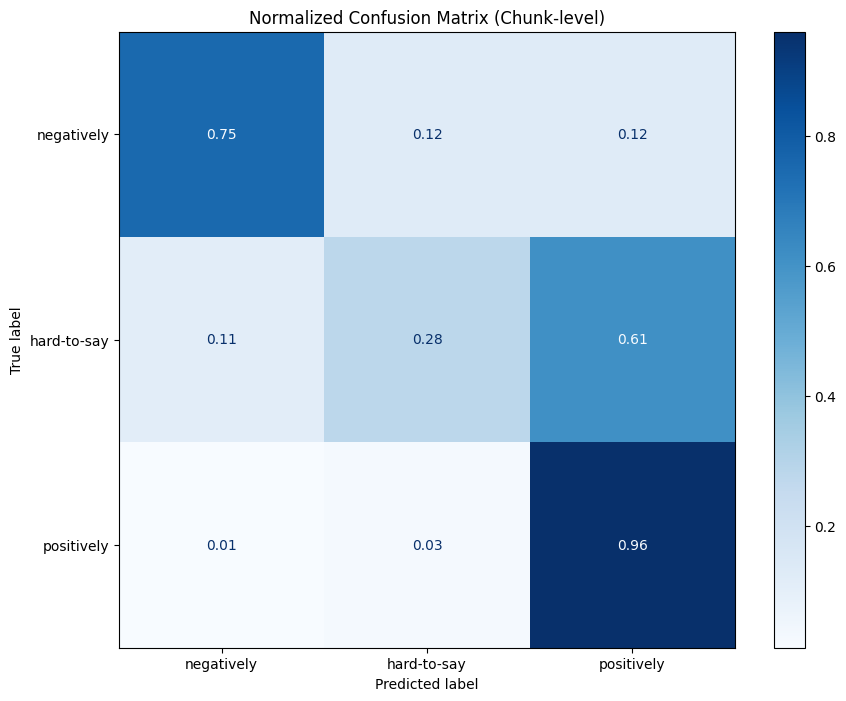

In [94]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [ ]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/Health_specific/health_df_ai_impact.parquet")
df_ai_impact.head()

,chunk_uid,url,date,title,topic_v0,chunk_text,topic,probability
0,49_0_0_0_0,https://www.wbay.com/prnewswire/2022/02/03/cus...,2022-02-03,"""From customer service to complex banking task...",4,"""From customer service to complex banking task...",0,1.0
1,50_0_0_0_0,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",4,"""From customer service to complex banking task...",0,1.0
2,50_0_0_0_1,https://www.asiaone.com/business/customer-serv...,2022-02-03,"""From customer service to complex banking task...",4,"Specifically, it is possible to guide how to u...",0,1.0
3,177_0_0_0_0,https://www.prnewswire.com/news-releases/the-r...,2025-11-03,"""The REAL AI Guide for Real Estate Agents"" Hit...",4,"""The REAL AI Guide for Real Estate Agents"" Hit...",0,1.0
4,177_0_0_0_1,https://www.prnewswire.com/news-releases/the-r...,2025-11-03,"""The REAL AI Guide for Real Estate Agents"" Hit...",4,Essential. Kevin brings the same clarity to AI...,0,1.0


In [95]:
print(df_ai_impact.shape)

(12850, 8)


In [96]:
from datasets import Dataset

df_ai_impact_pred = (
    df_ai_impact[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_ai_impact_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/12850 [00:00<?, ? examples/s]

In [97]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_impact_pred["pred_label_id"] = pred_ids
df_ai_impact_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_impact_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_impact_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_impact_pred.shape)
df_ai_impact_pred.head()

(12850, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,0_0_0_0_0,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",4,"""A Gift To Humanity"": AlphaFold AI Predicts St...",positively,0.779852,0.032504,0.187644,0.779852
1,0_0_0_0_1,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",4,"That may sound like a lot overall, but it’s th...",positively,0.937944,0.019015,0.043041,0.937944
2,0_0_0_1_0,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",4,Advertisement“It is allowing us to predict pro...,positively,0.945849,0.017189,0.036962,0.945849
3,9_0_0_0_0,https://celebritiesdeaths.com/antibiotic-disco...,2023-05-27,"""Antibiotic Discovery Using AI"": AI Aids Scien...",14,"""Antibiotic Discovery Using AI"": AI Aids Scien...",positively,0.943331,0.021252,0.035417,0.943331
4,9_0_0_0_1,https://celebritiesdeaths.com/antibiotic-disco...,2023-05-27,"""Antibiotic Discovery Using AI"": AI Aids Scien...",14,What’s Next for Abaucin? According to Jonathan...,positively,0.946778,0.019862,0.033360,0.946778


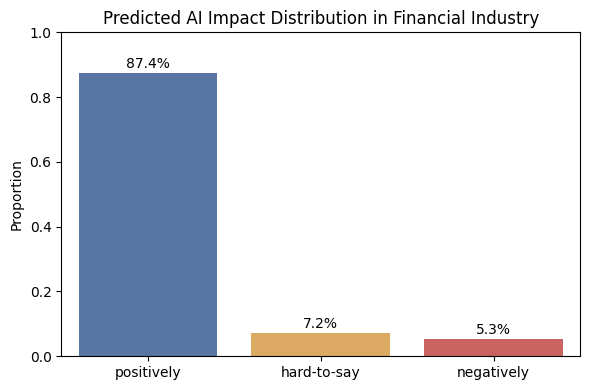

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_ai_impact_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in Financial Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [102]:
df_ai_impact_pred.to_parquet(f"{DATA_DIR}/Health_specific/{trained_model_name}_predictions.parquet", index=False)

### NER: Company and Technologies

In [4]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/Health_specific/health_ai_impact_classifier_predictions.parquet")
print(len(df_ai_impact_pred))
df_ai_impact_pred.head(2)

12850


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,0_0_0_0_0,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",4,"""A Gift To Humanity"": AlphaFold AI Predicts St...",positively,0.779852,0.032504,0.187644,0.779852
1,0_0_0_0_1,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",4,"That may sound like a lot overall, but it’s th...",positively,0.937944,0.019015,0.043041,0.937944


#### Positive impact

In [5]:
df_ai_impact_ner_sample_pos = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'positively'].sample(1000, random_state=38).reset_index(drop=True)

In [6]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [7]:
pos_entity_system_msg = """\
You are an information extraction system for healthcare-related news articles.

The user will provide a text block from a healthcare-related article.
Your task is to extract only the following:

1. organizations or companies in the healthcare ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or positive impact mechanisms explicitly mentioned in the text

## ORGANIZATIONS
Extract named healthcare-related organizations, companies, institutions, or agencies explicitly stated in the text.

This may include:
- hospitals and health systems
- pharmaceutical companies
- biotechnology firms
- medical device companies
- health-tech companies
- insurers or payers
- research institutes
- government or regulatory health agencies
- clinics, laboratory networks, or healthcare providers

Examples:
- Mayo Clinic
- Cleveland Clinic
- Pfizer
- Moderna
- UnitedHealth Group
- CVS Health
- Medtronic
- Tempus
- Illumina
- Epic Systems
- FDA
- NIH

## AI_TECHNOLOGIES_OR_MECHANISMS
Extract AI-related technologies, healthcare use cases, or impact mechanisms explicitly mentioned in the text.

This includes, but is not limited to:
- generative AI
- large language models
- machine learning
- clinical decision support
- diagnostic support
- medical imaging analysis
- radiology AI
- pathology AI
- patient monitoring
- workflow automation
- documentation automation
- cost reduction
- productivity improvement
- operational efficiency
- faster drug discovery
- biomarker discovery
- precision medicine
- risk prediction
- population health analytics

## Directions
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the hospital”, “the company”, “providers”, “health systems”, or “researchers” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [8]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    # 只保留非空字符串，并去重
    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [9]:
train_ai_positive_impact_ner = []

for idx, row in df_ai_impact_ner_sample_pos.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=pos_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_positive_impact_ner.append(result)
    
df_ai_positive_impact_ner_result = pd.DataFrame(train_ai_positive_impact_ner)

In [10]:
df_ai_positive_impact_ner_result

,organizations,ai_technologies_or_mechanisms,api_status,chunk_uid,title,text,pred_label,topic
0,"[AnX Robotica, FDA, Gemelli Hospital]","[AI Assisted Reading Tool, artificial intellig...",success,14525_0_0_0_0,Anx Robotica Announces FDA Clearance For Prosc...,Anx Robotica Announces FDA Clearance For Prosc...,positively,19
1,"[Nvidia, Deep Pharma Intelligence, Morgan Stan...","[AI-powered drug discovery, foundational model...",success,55788_1_1_0_0,Google DeepMind CEO: This is the next $100 bil...,"Nvidia is also in the game, partnering with AI...",positively,-1
2,"[Brigham and Women's Hospital, Mass General Br...","[artificial intelligence tools, accelerate the...",success,110185_0_0_0_0,Researchers use AI tools to uncover connection...,Researchers use AI tools to uncover connection...,positively,5
3,"[OPEN Health, Nested Knowledge]","[AI technologies, AI-based SaaS platform solut...",success,96594_0_0_0_0,OPEN Health and Nested Knowledge announce stra...,OPEN Health and Nested Knowledge announce stra...,positively,-1
4,"[Aidoc, UZ Brussel, GLEAMER]","[clinical AI, AI solutions, AI-based solutions...",success,10634_0_0_0_2,Aidoc Launches Seven New AI Solutions to Tackl...,About Aidoc\nAidoc is a pioneer in clinical AI...,positively,-1
...,...,...,...,...,...,...,...,...
995,"[Aidoc, Netherlands Cancer Institute, Reif & M...","[clinical AI platform, flag more pathologies, ...",success,10634_0_0_0_1,Aidoc Launches Seven New AI Solutions to Tackl...,"""Aidoc has already established itself as the l...",positively,-1
996,[],"[AlphaFold, artificial intelligence program, a...",success,115368_0_0_0_1,Scientists use AI to detect new family of gene...,"“But, we thought, other proteins like it must ...",positively,4
997,[WHO],"[AI tools for medicine, AI systems for assisti...",success,63076_1_0_0_0,How AI Can Expand Early Breast Cancer Detectio...,"However, the method developed by Dr. Lång stil...",positively,1
998,"[University of Oxford, Oxford Martin Program o...","[artificial intelligence, deep learning, rapid...",success,28453_0_0_0_0,Cara Diagnostik Anyar Nggunakake AI kanggo Nde...,Cara Diagnostik Anyar Nggunakake AI kanggo Nde...,positively,14


In [11]:
df_ai_positive_impact_ner_result.to_parquet(f"{DATA_DIR}/Health_specific/health_ai_positiveimpact_ner.parquet", index=False)

##### Organization 

In [12]:
df_ai_impact_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/Health_specific/health_ai_positiveimpact_ner.parquet")

In [13]:
df_posorg_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(2085, 2)
(348, 2)


,entity_raw,raw_count
0,FDA,49
1,Microsoft,39
2,Google,37
3,OpenAI,29
4,Mayo Clinic,22
...,...,...
343,Cleveland Clinic,2
344,Children’s National Hospital,2
345,AMA,2
346,care.ai,2


In [14]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

'- (FDA, 49)\n- (Microsoft, 39)\n- (Google, 37)\n- (OpenAI, 29)\n- (Mayo Clinic, 22)\n- (NHS, 18)\n- (DeepMind, 16)\n- (Insilico Medicine, 13)\n- (MIT, 13)\n- (Nvidia, 12)\n- (Google DeepMind, 10)\n- (Google Cloud, 10)\n- (GE Healthcare, 10)\n- (Epic, 9)\n- (NVIDIA, 8)\n- (University of Oxford, 8)\n- (Philips, 8)\n- (Abridge, 8)\n- (Intel Corporation, 8)\n- (Harvard Medical School, 8)\n- (Ibex Medical Analytics, 7)\n- (GE HealthCare, 7)\n- (Koninklijke Philips N.V., 7)\n- (Lunit, 7)\n- (NVIDIA Corporation, 7)\n- (Nabla, 7)\n- (Merck, 7)\n- (Atomwise, 7)\n- (CNBC, 7)\n- (Exscientia, 7)\n- (Aidoc, 7)\n- (Siemens Healthineers, 6)\n- (Medtronic, 6)\n- (Alphabet, 6)\n- (Wysa, 6)\n- (The Business Research Company, 6)\n- (University of Washington, 6)\n- (National Institutes of Health, 6)\n- (University of Pennsylvania, 6)\n- (Pfizer, 6)\n- (IBM, 6)\n- (Digital Diagnostics Inc., 5)\n- (Novartis, 5)\n- (Microsoft Corporation, 5)\n- (Bayer, 5)\n- (American Medical Association, 5)\n- (Recursion P

In [18]:
org_top_system_msg = """\
You are a company name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted from health-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same company into one canonical company name.
2. Classify canonical companies into:
   - health_industry_company
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 health industry companies
   - Top 10 AI companies

Rules:
- Be conservative when merging.
- Do not merge different companies.
- health_industry_company should be companies primarily in healthcare (hospitals, pharma, biotech, medtech, health systems).
- ai_company should be companies primarily in AI or health-tech with a strong AI focus.
- Use counts exactly as given.
- Media outlets, publications, and unclear entities should be ignored (not included in top lists).

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "health_industry_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "health_industry_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["health_industry_top10", "ai_top10"],
    "additionalProperties": False
}

In [19]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [20]:
industry_company_top10_pos = pd.DataFrame(result_posorg["health_industry_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Health Industry Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Health Industry Top 10


,canonical_name,total_count,source_raw_names
0,FDA,56,"[FDA, U.S. FDA, U.S. Food and Drug Administrat..."
1,Mayo Clinic,22,[Mayo Clinic]
2,NHS,21,"[NHS, NHS England]"
3,GE Healthcare,17,"[GE Healthcare, GE HealthCare]"
4,Philips,15,"[Philips, Koninklijke Philips N.V.]"
5,Epic,11,"[Epic, Epic Systems Corporation]"
6,Merck,9,"[Merck, Merck KGaA]"
7,Siemens Healthineers,8,"[Siemens Healthineers, Siemens Healthineers AG..."
8,Medtronic,10,"[Medtronic, Medtronic plc]"
9,Pfizer,6,[Pfizer]


AI Top 10


,canonical_name,total_count,source_raw_names
0,Microsoft,46,"[Microsoft, Microsoft Corporation, Microsoft A..."
1,Google,49,"[Google, Google Cloud, Google DeepMind, Google..."
2,OpenAI,31,"[OpenAI, Open AI]"
3,DeepMind,16,[DeepMind]
4,Nvidia,27,"[Nvidia, NVIDIA, NVIDIA Corporation]"
5,IBM,12,"[IBM, IBM Corporation, IBM Watson Health, Inte..."
6,Insilico Medicine,13,[Insilico Medicine]
7,Abridge,8,[Abridge]
8,Exscientia,7,[Exscientia]
9,Atomwise,9,"[Atomwise, Atomwise Inc.]"


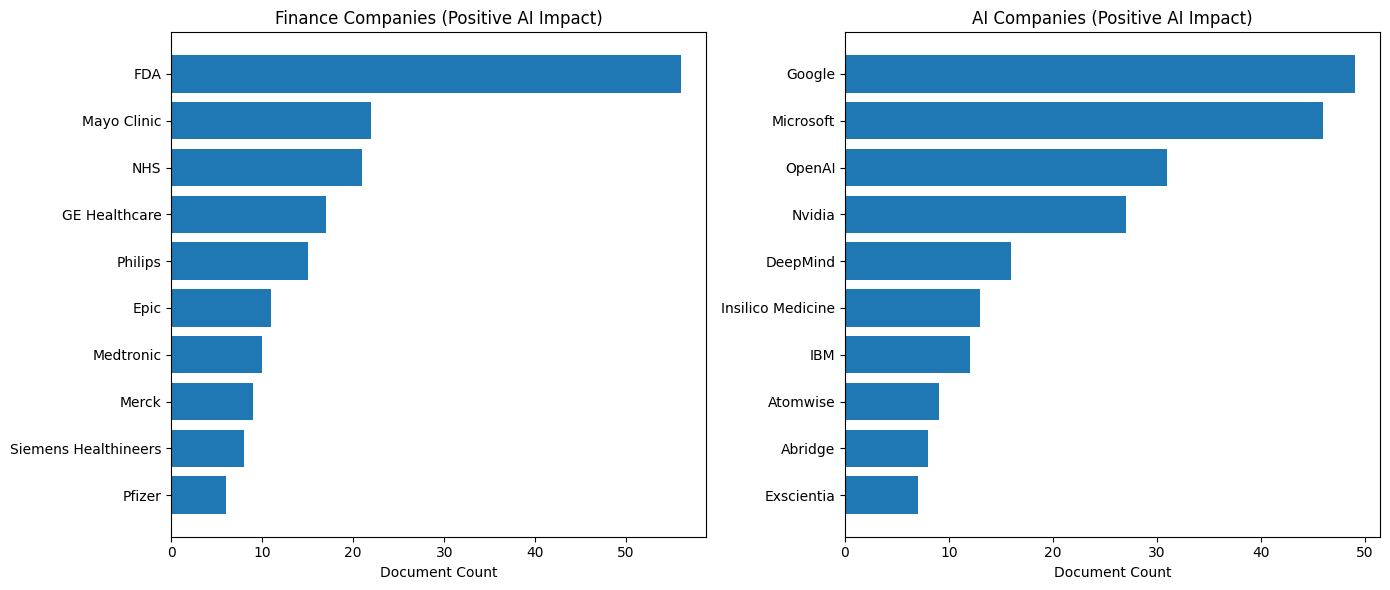

In [21]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Finance Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [22]:
df_posmech_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(4183, 2)
(439, 2)


,entity_raw,raw_count
0,machine learning,136
1,artificial intelligence,119
2,AI,85
3,generative AI,84
4,workflow automation,50
...,...,...
434,AI-generated message,2
435,AI-led drug discovery methodology,2
436,K-nearest neighbors,2
437,Machine Learning (ML),2


In [23]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

'- (machine learning, 136)\n- (artificial intelligence, 119)\n- (AI, 85)\n- (generative AI, 84)\n- (workflow automation, 50)\n- (ChatGPT, 48)\n- (operational efficiency, 37)\n- (drug discovery, 35)\n- (diagnostic support, 34)\n- (large language models, 33)\n- (deep learning, 30)\n- (AI algorithms, 28)\n- (productivity improvement, 28)\n- (precision medicine, 28)\n- (Artificial Intelligence, 22)\n- (AI models, 20)\n- (predictive analytics, 20)\n- (clinical decision support, 20)\n- (faster drug discovery, 19)\n- (cost reduction, 19)\n- (AI model, 17)\n- (documentation automation, 17)\n- (early detection, 16)\n- (risk prediction, 15)\n- (AI tools, 15)\n- (AI platform, 15)\n- (automation, 12)\n- (natural language processing, 12)\n- (AlphaFold, 12)\n- (patient monitoring, 11)\n- (artificial intelligence (AI), 11)\n- (AI tool, 10)\n- (Artificial Intelligence (AI), 10)\n- (reduce costs, 10)\n- (personalized medicine, 10)\n- (efficiency, 10)\n- (Machine Learning, 9)\n- (radiology AI, 9)\n- (dr

In [ ]:
posmech_top_system_msg = """\
You are an AI technology and healthcare impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from healthcare-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_healthcare_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI healthcare mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.


### ai_healthcare_mechanism
Healthcare applications, operational impacts, or clinical/research mechanisms through which AI affects healthcare systems.


### other
Anything vague, unclear, or not clearly an AI technology or healthcare mechanism.


Rules:
- Merge only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_healthcare_mechanism when the healthcare context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models class.


Return valid JSON only.
"""

mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [32]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [33]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,machine learning,155,"[machine learning, Machine Learning, ML, machi..."
1,artificial intelligence,156,"[artificial intelligence, AI, Artificial Intel..."
2,generative AI,95,"[generative AI, Generative AI, generative arti..."
3,large language models,49,"[ChatGPT, large language models, large languag..."
4,deep learning,47,"[deep learning, Deep Learning, deep learning m..."
5,natural language processing,18,"[natural language processing, Natural Language..."
6,AlphaFold,17,"[AlphaFold, AlphaFold2, AlphaFold 3, AlphaFold..."
7,computer vision,7,[computer vision]
8,federated learning,3,[federated learning]
9,reinforcement learning,5,"[reinforcement learning, Reinforcement Learning]"


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,workflow automation,50,[workflow automation]
1,operational efficiency,37,"[operational efficiency, operational efficienc..."
2,drug discovery,68,"[drug discovery, faster drug discovery, drug d..."
3,diagnostic support,34,[diagnostic support]
4,productivity improvement,28,[productivity improvement]
5,precision medicine,28,[precision medicine]
6,predictive analytics,20,[predictive analytics]
7,clinical decision support,20,[clinical decision support]
8,cost reduction,29,"[cost reduction, reduce costs, cost savings, r..."
9,documentation automation,17,[documentation automation]


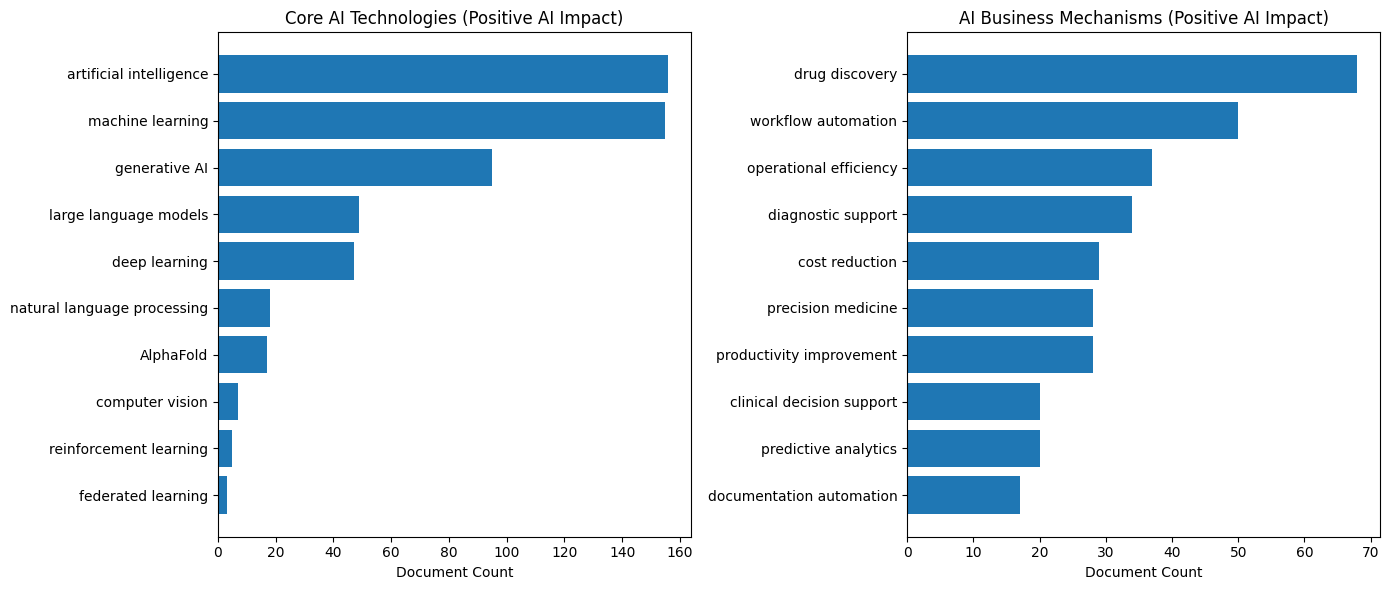

In [34]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Negative impact

In [37]:
df_ai_negative_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'negatively'].sample(500, random_state=42).reset_index(drop=True)
print(len(df_ai_negative_impact_ner_sample))

500


In [38]:
neg_entity_system_msg = """\
You are an information extraction system for healthcare-related news articles.

The user will provide a text block from a healthcare-related article.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or institutions in the healthcare ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS
Extract named healthcare-related organizations, companies, or institutions explicitly stated in the text.

This may include:
- hospitals or health systems
- pharmaceutical companies
- biotechnology firms
- medical device companies
- health technology companies
- insurers or healthcare payers
- research institutes
- regulators or public health agencies

Examples:
- Mayo Clinic
- Cleveland Clinic
- Kaiser Permanente
- UnitedHealth Group
- Pfizer
- Moderna
- Medtronic
- Illumina
- Epic Systems
- FDA
- NIH


## AI_TECHNOLOGIES_OR_MECHANISMS
Extract:

- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related NEGATIVE healthcare impact mechanisms explicitly mentioned in the text


Examples of technologies / capabilities:
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- natural language processing
- medical imaging AI
- diagnostic AI


Examples of NEGATIVE healthcare impact mechanisms:
- diagnostic errors
- misdiagnosis
- unsafe clinical recommendations
- patient safety risks
- delayed treatment
- algorithmic bias
- healthcare inequity
- patient data leakage
- privacy violations
- regulatory scrutiny
- FDA compliance risk
- malpractice liability
- clinician burden
- workflow disruption
- failed AI deployment
- overreliance on AI
- loss of trust in healthcare systems


## Directions
- Focus especially on negative AI-related mechanisms, risks, harms, and downsides in healthcare.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the hospital”, “the company”, “health systems”, or “providers” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [39]:
train_ai_negative_impact_ner = []

for idx, row in df_ai_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_negative_impact_ner.append(result)
    
df_ai_negative_impact_ner_result = pd.DataFrame(train_ai_negative_impact_ner)

In [40]:
df_ai_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/Health_specific/finance_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [41]:
df_negorg_long = (
    df_ai_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(651, 2)
(146, 2)


,entity_raw,raw_count
0,OpenAI,37
1,FDA,34
2,Google,25
3,Microsoft,14
4,NHS,11
...,...,...
141,European Union,2
142,Duke University,2
143,Else Kröner Fresenius Center for Digital Health,2
144,Xoltar,2


In [42]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

"- (OpenAI, 37)\n- (FDA, 34)\n- (Google, 25)\n- (Microsoft, 14)\n- (NHS, 11)\n- (Stanford University, 7)\n- (HHS, 6)\n- (AMA, 6)\n- (World Health Organization, 6)\n- (McKinsey, 6)\n- (Mayo Clinic, 5)\n- (Anthropic, 5)\n- (Harvard Medical School, 5)\n- (Kaiser Permanente, 5)\n- (Medicare, 5)\n- (Stanford School of Medicine, 4)\n- (University of Texas San Antonio, 4)\n- (WHO, 4)\n- (Epic, 4)\n- (NHS England, 4)\n- (KFF, 4)\n- (Mass General Brigham, 4)\n- (Nabla, 4)\n- (Thriveworks, 4)\n- (Meta, 3)\n- (NPR, 3)\n- (GE Healthcare, 3)\n- (Colorado School of Public Health, 3)\n- (Washington University, 3)\n- (University of California San Diego, 3)\n- (Accenture, 3)\n- (Wysa, 3)\n- (WMA, 3)\n- (Hone Health, 3)\n- (Montreal Children's Hospital, 3)\n- (Mount Sinai Health System, 3)\n- (Centers for Disease Control and Prevention (CDC), 3)\n- (Cleveland Clinic, 3)\n- (Long Island University, 3)\n- (Nuffield Trust, 3)\n- (Stacker, 3)\n- (University of Colorado's Anschutz Medical Campus, 3)\n- (Brig

In [44]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [45]:
industry_company_top10_neg = pd.DataFrame(result_negorg["health_industry_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("Health Industry Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

Health Industry Top 10


,canonical_name,total_count,source_raw_names
0,Mayo Clinic,5,[Mayo Clinic]
1,Kaiser Permanente,5,[Kaiser Permanente]
2,Epic,4,[Epic]
3,Mass General Brigham,4,[Mass General Brigham]
4,Mount Sinai Health System,3,[Mount Sinai Health System]
5,Cleveland Clinic,3,[Cleveland Clinic]
6,Brigham and Women's Hospital,3,[Brigham and Women’s Hospital]
7,Northwestern Medicine,3,[Northwestern Medicine]
8,Pfizer,3,[Pfizer]
9,Humana,3,[Humana]


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,40,"[OpenAI, Open AI]"
1,Google,27,"[Google, Google's DeepMind]"
2,Microsoft,14,[Microsoft]
3,Anthropic,5,[Anthropic]
4,Nabla,4,[Nabla]
5,Meta,3,[Meta]
6,Wysa,3,[Wysa]
7,Qventus,3,[Qventus]
8,Variational AI,2,[Variational AI]
9,Nuance Communications,2,[Nuance Communications]


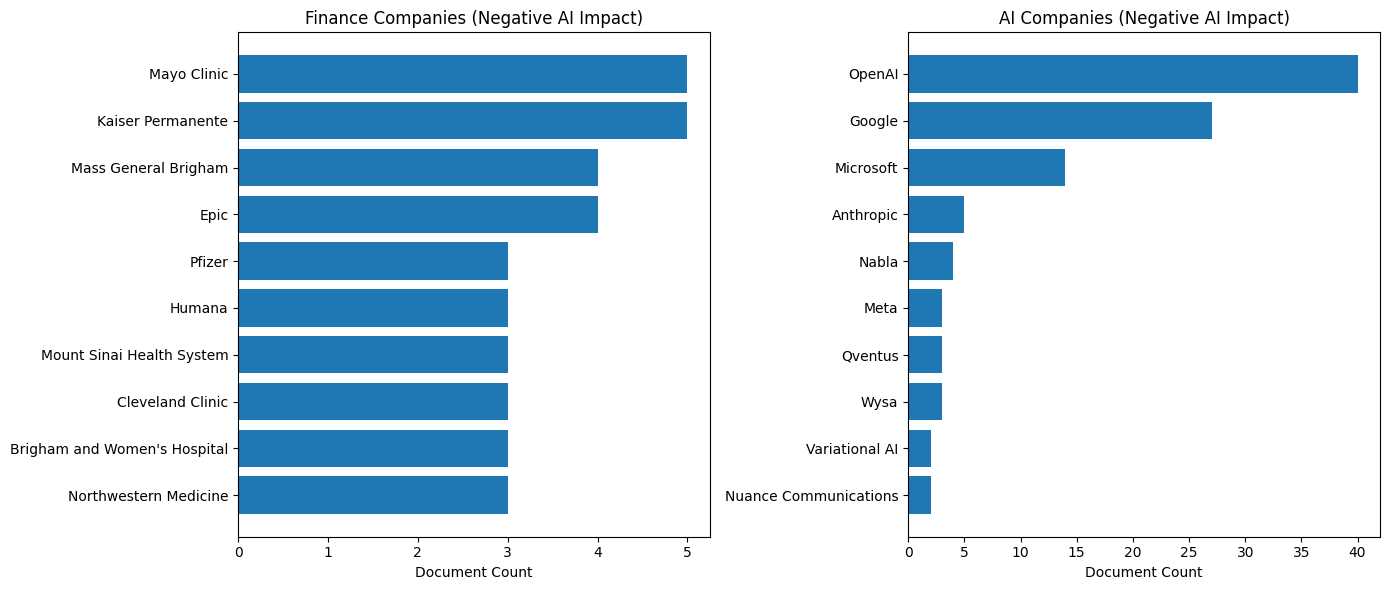

In [46]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Finance Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [47]:
df_ai_mech_long_neg = (
    df_ai_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(1538, 2)
(234, 2)


,entity_raw,raw_count
0,patient safety risks,106
1,unsafe clinical recommendations,90
2,algorithmic bias,89
3,ChatGPT,77
4,overreliance on AI,74
...,...,...
229,wrong treatment suggestions,2
230,wrong information,2
231,wrong answers,2
232,wrong answer to the question of whether a drug...,2


In [48]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

"- (patient safety risks, 106)\n- (unsafe clinical recommendations, 90)\n- (algorithmic bias, 89)\n- (ChatGPT, 77)\n- (overreliance on AI, 74)\n- (loss of trust in healthcare systems, 74)\n- (diagnostic errors, 59)\n- (privacy violations, 49)\n- (healthcare inequity, 49)\n- (failed AI deployment, 42)\n- (generative AI, 38)\n- (AI chatbots, 38)\n- (regulatory scrutiny, 38)\n- (misdiagnosis, 36)\n- (patient data leakage, 32)\n- (machine learning, 28)\n- (AI, 28)\n- (large language models, 25)\n- (AI models, 21)\n- (artificial intelligence, 19)\n- (AI tools, 19)\n- (workflow disruption, 16)\n- (AI systems, 15)\n- (delayed treatment, 15)\n- (AI algorithms, 14)\n- (chatbots, 13)\n- (AI chatbot, 13)\n- (bias, 10)\n- (malpractice liability, 10)\n- (clinician burden, 9)\n- (algorithms, 8)\n- (data privacy, 8)\n- (GPT-4, 7)\n- (natural language processing, 7)\n- (AI scribes, 6)\n- (hallucinations, 6)\n- (misinformation, 6)\n- (transparency, 6)\n- (predictive analytics, 6)\n- (misdiagnose health

In [49]:
neg_mech_top_system_msg = """\
You are an AI technology and healthcare impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts extracted from healthcare-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_healthcare_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI healthcare mechanisms

Definitions:

### core_ai_technology
Fundamental AI technologies, models, or technical approaches.


### ai_healthcare_mechanism
Healthcare applications, operational impacts, or clinical/research mechanisms through which AI affects healthcare systems.
Focus on negative impact mechanisms, risks, harms, and downsides in healthcare.

### other
Anything vague, unclear, or not clearly an AI technology or healthcare mechanism.


Rules:
- Merge only when raw names clearly refer to the same concept.
- Be conservative when merging.
- Keep canonical names concise and representative.
- Do not invent new concepts that are not supported by the provided raw names.
- Use counts exactly as provided.
- Only classify items as ai_healthcare_mechanism when the healthcare context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models class.


Return valid JSON only.
"""


In [50]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)
result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [51]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,machine learning,60,"[machine learning, AI, artificial intelligence..."
1,large language models,119,"[ChatGPT, large language models, generative AI..."
2,natural language processing,7,[natural language processing]
3,predictive analytics,9,"[predictive analytics, predictive modeling, pr..."
4,federated learning,2,[federated learning]
5,ambient voice technology,2,[ambient voice technology]
6,AI scribes,6,[AI scribes]
7,diagnostic AI,4,[diagnostic AI]
8,health apps,2,[health apps]
9,clinical decision-making support,2,[clinical decision-making support]


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,patient safety risks,106,[patient safety risks]
1,unsafe clinical recommendations,90,[unsafe clinical recommendations]
2,algorithmic bias,108,"[algorithmic bias, bias, biases, biased data, ..."
3,overreliance on AI,78,"[overreliance on AI, over-reliance on AI, auto..."
4,loss of trust in healthcare systems,74,[loss of trust in healthcare systems]
5,diagnostic errors,110,"[diagnostic errors, misdiagnosis, misdiagnose ..."
6,privacy violations,68,"[privacy violations, patient data leakage, dat..."
7,healthcare inequity,58,"[healthcare inequity, worsen health disparitie..."
8,failed AI deployment,42,[failed AI deployment]
9,regulatory scrutiny,49,"[regulatory scrutiny, FDA compliance risk, reg..."


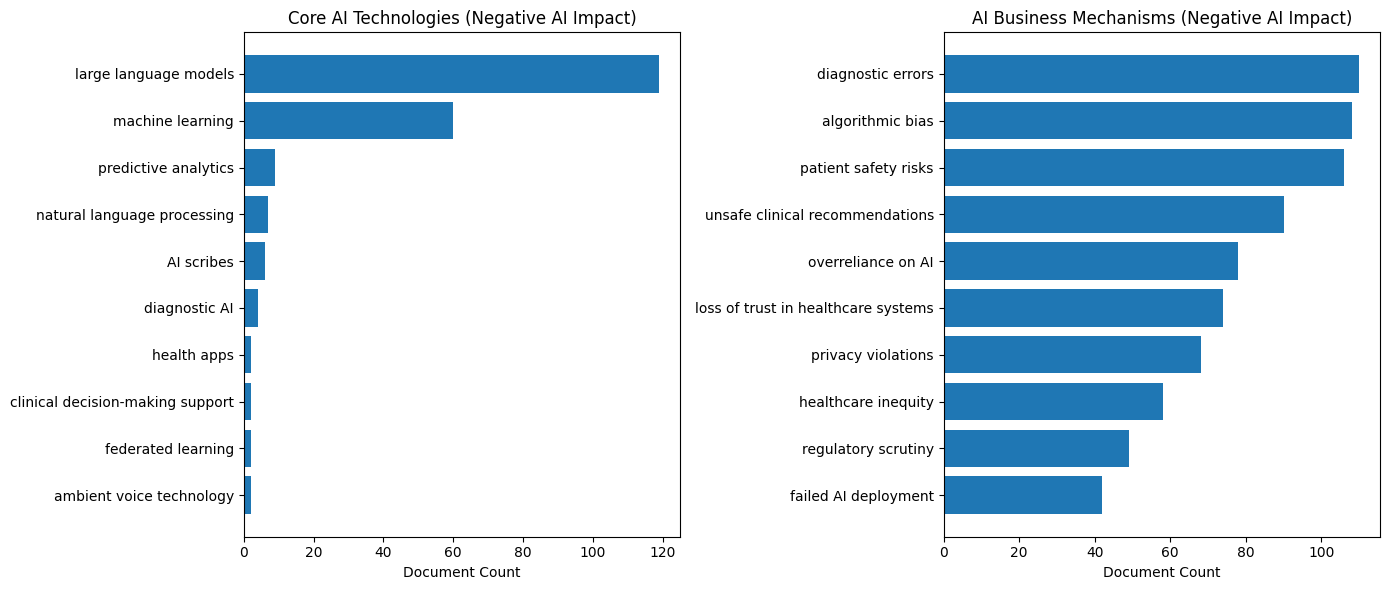

In [52]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [53]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/Health_specific/health_ai_impact_classifier_predictions.parquet")

#### Topic Aggregation

In [56]:
Health_topics = pd.read_csv(f"{DATA_DIR}/Health_specific/Health_topics.csv")[['Topic','Representation','Representative_Docs']].copy()
Health_chunks_topics = pd.read_parquet(f"{DATA_DIR}/Health_specific/Health_chunks_topics.parquet")

In [61]:
Health_topics = Health_topics[Health_topics['Topic'] != -1]
Health_topics

,Topic,Representation,Representative_Docs,topic_summary
1,0,"['intelligence drug', 'discovery market', 'ins...",['PESTLE Analysis4.2.5. Artificial Intelligenc...,This topic is about using artificial intellige...
2,1,"['lunit', 'tumor', 'mammograms', 'mammography'...","['Study Validates Lunit AI as a Game-Changer, ...",Lunit's AI solutions enhance cancer detection ...
3,2,"['chatbot', 'gpt-', 'exam', 'chatgpt health', ...",['ChatGPT nearly passes radiology board exam -...,AI chatbots like ChatGPT and Med-PaLM are bein...
4,3,"['therapist', 'therapists', 'chatbot', 'emotio...",['The (artificial intelligence) therapist can ...,AI chatbots providing mental health therapy to...
5,4,"['protein', 'proteins', 'alphafold', 'deepmind...","['The project was first announced in 2018, but...",AlphaFold's AI breakthrough in accurately pred...
6,5,"['ecg', 'heart failure', 'cardiovascular disea...",['Researchers use artificial intelligence to p...,This topic is about using AI to predict and an...
7,6,"['healthcare market', 'market research', 'cagr...",['AI in Healthcare Market Growth Outlook | Ind...,This topic is about the rapidly growing market...
8,7,"['biases', 'racial', 'biased', 'black patients...",['What the researchers focused on: Previous re...,AI detecting race from medical images raises c...
9,8,"['terarecon', 'philips', 'rad', 'sirona', 'con...",['ConcertAI\'s TeraRecon Brings Neuro-oncology...,This topic is about AI-powered medical imaging...
10,9,"['hippocratic', 'scribe', 'epic', 'ambient', '...","['ScribeRyte AI Plus – High Tech, High TouchA ...",AI-powered medical scribe solutions to automat...


In [ ]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in Health_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

Health_topics["topic_summary"] = summaries
show_full(Health_topics[["Topic", "Representation", "topic_summary"]])

,Topic,Representation,topic_summary
1,0,"['intelligence drug', 'discovery market', 'insilico', 'genomics', 'molecules', 'candidates', 'lilly', 'molecule', 'discovery development', 'recursion']",This topic is about using artificial intelligence to accelerate and improve drug discovery and development.
2,1,"['lunit', 'tumor', 'mammograms', 'mammography', 'cancer detection', 'digital pathology', 'immune', 'cancer diagnostics', 'tumors', 'immunotherapy']",Lunit's AI solutions enhance cancer detection and diagnostics in mammography and digital pathology.
3,2,"['chatbot', 'gpt-', 'exam', 'chatgpt health', 'medical licensing', 'licensing', 'med-palm', 'usmle', 'messages', 'medical education']",AI chatbots like ChatGPT and Med-PaLM are being tested for medical exams and healthcare applications.
4,3,"['therapist', 'therapists', 'chatbot', 'emotional', 'depression', 'wysa', 'jacobson', 'adhd', 'health support', 'ali']",AI chatbots providing mental health therapy to address provider shortages.
5,4,"['protein', 'proteins', 'alphafold', 'deepmind', 'sequences', 'amino', 'enzymes', 'mutations', 'sequence', 'protein structures']",DeepMind's AlphaFold uses AI to predict protein structures with high accuracy.
6,5,"['ecg', 'heart failure', 'cardiovascular disease', 'coronary', 'heart attack', 'atrial', 'heart attacks', 'fibrillation', 'atrial fibrillation', 'cardiology']",This topic is about using AI to predict and analyze cardiovascular diseases like heart failure and atrial fibrillation.
7,6,"['healthcare market', 'market research', 'cagr', 'market size', 'usd', 'usd billion', 'market growth', 'forecast period', 'market report', 'remote patient']",This topic is about the rapid market growth and financial forecasts for artificial intelligence in the healthcare industry.
8,7,"['biases', 'racial', 'biased', 'black patients', 'white patients', 'fairness', 'racial bias', 'data privacy', 'healthcare industry', 'medical images']",AI detecting race from medical images raises concerns about bias and fairness in healthcare.
9,8,"['terarecon', 'philips', 'rad', 'sirona', 'concertai', 'eureka', 'radiologist', 'eureka clinical', 'omni', 'pacs']","This topic is about AI-powered medical imaging platforms, specifically TeraRecon's Eureka Clinical AI, for radiology and oncology diagnostics."
10,9,"['hippocratic', 'scribe', 'epic', 'ambient', 'burnout', 'copilot', 'veterinary', 'scribes', 'oracle', 'scriberyte']",AI-powered medical scribe solutions to automate clinical documentation and reduce physician burnout.


In [63]:
Health_topics_summary = Health_topics[["Topic", "Representation", "topic_summary"]].copy()

In [64]:
meta_topic_system_msg = """
You are a healthcare AI industry analyst.

The user will provide a list of lower-level topics extracted from healthcare AI news.

Each topic includes:
- Topic ID
- keyword representation
- short topic summary

Your task:
Group these topics into 3 to 5 higher-level healthcare AI themes.

Requirements:
- Create 3 to 5 meta-topics
- Assign every Topic ID to exactly one meta-topic
- Give each meta-topic:
  - meta_topic_label
  - meta_topic_summary
  - topic_ids (list of topic IDs)

Return JSON only.

Format:
{
  "meta_topics":[
    {
      "meta_topic_label":"...",
      "meta_topic_summary":"...",
      "topic_ids":[0,1,2]
    }
  ]
}
"""

topics_text = "\n\n".join(
    Health_topics_summary.apply(
        lambda r: f"""
Topic ID: {r['Topic']}
Keywords: {r['Representation']}
Summary: {r['topic_summary']}
""",
        axis=1
    )
)

user_msg = f"""
Group the following healthcare AI topics into 3–5 higher-level themes.

Topics:
{topics_text}

Return JSON only.
"""

meta_topic_schema = {
    "type": "object",
    "properties": {
        "meta_topics": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "meta_topic_label": {"type": "string"},
                    "meta_topic_summary": {"type": "string"},
                    "topic_ids": {
                        "type": "array",
                        "items": {"type": "integer"}
                    }
                },
                "required": ["meta_topic_label", "meta_topic_summary", "topic_ids"],
                "additionalProperties": False
            },
            "minItems": 3,
            "maxItems": 5
        }
    },
    "required": ["meta_topics"],
    "additionalProperties": False
}

In [65]:
import json

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": meta_topic_system_msg},
        {"role": "user", "content": user_msg}
    ],
    temperature=0,
    response_format={"type": "json_object"}
)

meta_topics = json.loads(response.choices[0].message.content)

meta_topics

{'meta_topics': [{'meta_topic_label': 'AI in Clinical Diagnostics and Imaging',
   'meta_topic_summary': 'AI applications for detecting, diagnosing, and monitoring diseases through medical imaging and diagnostic tools, including cancer, cardiovascular, neurodegenerative, and other conditions.',
   'topic_ids': [1, 5, 8, 12, 16, 19, 20]},
  {'meta_topic_label': 'AI in Drug Discovery and Biomedical Research',
   'meta_topic_summary': 'AI-driven approaches to accelerate drug development, predict protein structures, identify antibiotic resistance, and advance biomedical research.',
   'topic_ids': [0, 4, 14]},
  {'meta_topic_label': 'AI in Clinical Workflow and Administrative Support',
   'meta_topic_summary': 'AI tools to automate clinical documentation, assist in surgery, manage administrative tasks, and reduce healthcare provider burnout.',
   'topic_ids': [9, 15]},
  {'meta_topic_label': 'AI in Patient Interaction and Education',
   'meta_topic_summary': 'AI chatbots and assistants for

In [67]:
rows = []

for m in meta_topics["meta_topics"]:
    for t in m["topic_ids"]:
        rows.append({
            "Topic": t,
            "meta_topic": m["meta_topic_label"],
            "meta_summary": m["meta_topic_summary"]
        })

df_meta = pd.DataFrame(rows)
Health_topics_5 = Health_topics_summary.merge(df_meta, on="Topic", how="left")
Health_topics_5

,Topic,Representation,topic_summary,meta_topic,meta_summary
0,0,"['intelligence drug', 'discovery market', 'ins...",This topic is about using artificial intellige...,AI in Drug Discovery and Biomedical Research,AI-driven approaches to accelerate drug develo...
1,1,"['lunit', 'tumor', 'mammograms', 'mammography'...",Lunit's AI solutions enhance cancer detection ...,AI in Clinical Diagnostics and Imaging,"AI applications for detecting, diagnosing, and..."
2,2,"['chatbot', 'gpt-', 'exam', 'chatgpt health', ...",AI chatbots like ChatGPT and Med-PaLM are bein...,AI in Patient Interaction and Education,AI chatbots and assistants for mental health t...
3,3,"['therapist', 'therapists', 'chatbot', 'emotio...",AI chatbots providing mental health therapy to...,AI in Patient Interaction and Education,AI chatbots and assistants for mental health t...
4,4,"['protein', 'proteins', 'alphafold', 'deepmind...",DeepMind's AlphaFold uses AI to predict protei...,AI in Drug Discovery and Biomedical Research,AI-driven approaches to accelerate drug develo...
5,5,"['ecg', 'heart failure', 'cardiovascular disea...",This topic is about using AI to predict and an...,AI in Clinical Diagnostics and Imaging,"AI applications for detecting, diagnosing, and..."
6,6,"['healthcare market', 'market research', 'cagr...",This topic is about the rapid market growth an...,"Healthcare AI Market, Regulation, and Ethics","Market growth analysis, regulatory frameworks,..."
7,7,"['biases', 'racial', 'biased', 'black patients...",AI detecting race from medical images raises c...,"Healthcare AI Market, Regulation, and Ethics","Market growth analysis, regulatory frameworks,..."
8,8,"['terarecon', 'philips', 'rad', 'sirona', 'con...",This topic is about AI-powered medical imaging...,AI in Clinical Diagnostics and Imaging,"AI applications for detecting, diagnosing, and..."
9,9,"['hippocratic', 'scribe', 'epic', 'ambient', '...",AI-powered medical scribe solutions to automat...,AI in Clinical Workflow and Administrative Sup...,"AI tools to automate clinical documentation, a..."


In [68]:
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["doc_id"].astype(int)
df_ai_impact_pred['meta_topic'] = df_ai_impact_pred['topic'].map(Health_topics_5.set_index("Topic")["meta_topic"])

display(df_ai_impact_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id,meta_topic
0,0_0_0_0_0,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",4,"""A Gift To Humanity"": AlphaFold AI Predicts St...",positively,0.779852,0.032504,0.187644,0.779852,0,AI in Drug Discovery and Biomedical Research
1,0_0_0_0_1,https://www.iflscience.com/a-gift-to-humanity-...,2022-07-28,"""A Gift To Humanity"": AlphaFold AI Predicts St...",4,"That may sound like a lot overall, but it’s th...",positively,0.937944,0.019015,0.043041,0.937944,0,AI in Drug Discovery and Biomedical Research


In [69]:
# Group by meta_topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["meta_topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="meta_topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("meta_topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("meta_topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
aiimpact_topic_label_doc_prop_pct

pred_label,meta_topic,hard-to-say,negatively,positively
0,AI in Clinical Diagnostics and Imaging,70,41,1205
1,AI in Clinical Workflow and Administrative Sup...,5,4,217
2,AI in Drug Discovery and Biomedical Research,81,28,899
3,AI in Patient Interaction and Education,149,140,465
4,"Healthcare AI Market, Regulation, and Ethics",133,71,476


pred_label,meta_topic,hard-to-say,negatively,positively
0,AI in Clinical Diagnostics and Imaging,5.32%,3.12%,91.57%
1,AI in Clinical Workflow and Administrative Sup...,2.21%,1.77%,96.02%
2,AI in Drug Discovery and Biomedical Research,8.04%,2.78%,89.19%
3,AI in Patient Interaction and Education,19.76%,18.57%,61.67%
4,"Healthcare AI Market, Regulation, and Ethics",19.56%,10.44%,70.0%


In [70]:
# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,meta_topic,hard-to-say,negatively,positively,impact_score
0,AI in Clinical Diagnostics and Imaging,0.053191,0.031155,0.915653,0.884498
1,AI in Clinical Workflow and Administrative Sup...,0.022124,0.017699,0.960177,0.942478
2,AI in Drug Discovery and Biomedical Research,0.080357,0.027778,0.891865,0.864087
3,AI in Patient Interaction and Education,0.197613,0.185676,0.616711,0.431034
4,"Healthcare AI Market, Regulation, and Ethics",0.195588,0.104412,0.700000,0.595588


The correction assumes that the observed predicted label distribution is a noisy transformation of the true label distribution.

The confusion matrix describes how true labels are converted into predicted labels.

By inverting this transformation, we estimate the underlying true distribution of labels at the topic level.

In [71]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.75, 0.12, 0.12],
    [0.11, 0.28, 0.61],
    [0.01, 0.03, 0.96]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,meta_topic,hard-to-say,negatively,positively,impact_score_corrected
0,AI in Clinical Diagnostics and Imaging,0.086657,0.016870,0.896473,0.879603
1,AI in Clinical Workflow and Administrative Sup...,0.000000,0.015178,0.984822,0.969644
2,AI in Drug Discovery and Biomedical Research,0.201970,0.000000,0.798030,0.798030
3,AI in Patient Interaction and Education,0.613767,0.154072,0.232161,0.078088
4,"Healthcare AI Market, Regulation, and Ethics",0.647637,0.040009,0.312355,0.272346


Topic 1 collapses to hard-to-say

Because:

- It has moderate hard-to-say presence (27%).

- The confusion matrix says 71% of true hard-to-say gets predicted positive.

- Therefore the large predicted positive mass can be fully “explained” by hard-to-say leakage.

- The inversion essentially says:


“This topic is not truly positive — it is mostly ambiguous.”

#### Entity Aggregation

**This part has already been done in the NER Part.**

My current approach estimates:

$P(entity \mid sentiment)$

That is:

Given that a text expresses a certain sentiment (positive or negative AI impact), which entities appear most frequently?

This is a sentiment-conditioned entity frequency analysis.

It answers a framing question:In positive AI impact narratives, who and what are being discussed?

A common alternative estimates:

$P(sentiment \mid entity)$

That is:

Given that an entity appears, what is the sentiment distribution of the texts mentioning it?

In practice, it's: 
	1.	Collect all texts mentioning each entity.
	2.	Aggregate their sentiment labels.
	3.	Compute a sentiment score per entity.

This is an entity-conditioned sentiment analysis.

It answers an attribution question: Is this company typically discussed positively or negatively in AI contexts?

They are related through Bayes’ rule:

$$
P(entity \mid sentiment) =
\frac{P(sentiment \mid entity)\,P(entity)}{P(sentiment)}
$$

But they are not symmetric.

- $P(entity \mid sentiment)$ focuses on narrative composition.

- $P(sentiment \mid entity)$ focuses on reputational evaluation.

They answer different analytical questions.


Why My Approach Is More Suitable for This Project

The project aims to understand:

How AI impact discourse is constructed across positive and negative narratives.

In that context, $P(entity \mid sentiment)$ is more intuitive and aligned with your research goal because:

1. It directly reflects narrative framing. I am examining who and what appear in positive versus negative AI impact discussions.

2. It is structurally simpler given your data. My sentiment labels are assigned at the text level.

    Computing $P(sentiment \mid entity)$ would require:
        •	Aggregating texts per entity,
        •	Handling multi-entity texts,
        •	Addressing overlapping mentions,
        •	Managing small-sample instability.

3.	It avoids instability issues. Entity-level sentiment scores can become noisy for entities with few mentions.

4.	It preserves interpretability: “Top entities in positive AI narratives” is more straightforward to explain than per-entity sentiment attribution.

#### Time Aggregation

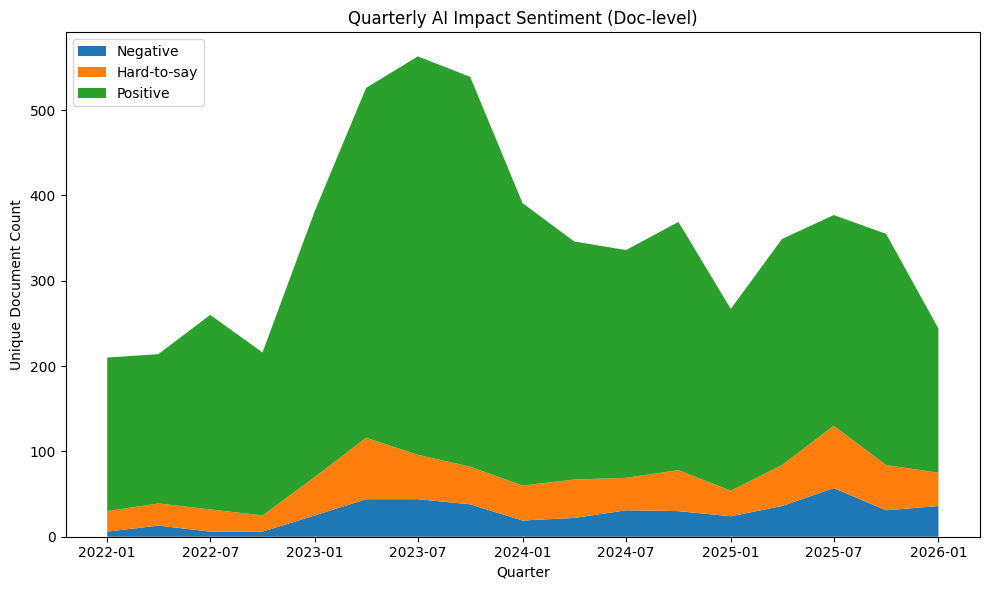

In [72]:
df_ai_impact_pred["date"] = pd.to_datetime(df_ai_impact_pred["date"])
df_ai_impact_pred["quarter"] = df_ai_impact_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_ai_impact_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

pred_label,hard-to-say,negatively,positively
quarter,,,
2022-01-01,0.114286,0.028571,0.857143
2022-04-01,0.121495,0.060748,0.817757
2022-07-01,0.100000,0.023077,0.876923
2022-10-01,0.087963,0.027778,0.884259
2023-01-01,0.117801,0.065445,0.816754
2023-04-01,0.136882,0.083650,0.779468
2023-07-01,0.092362,0.078153,0.829485
2023-10-01,0.081633,0.070501,0.847866
2024-01-01,0.104859,0.048593,0.846547


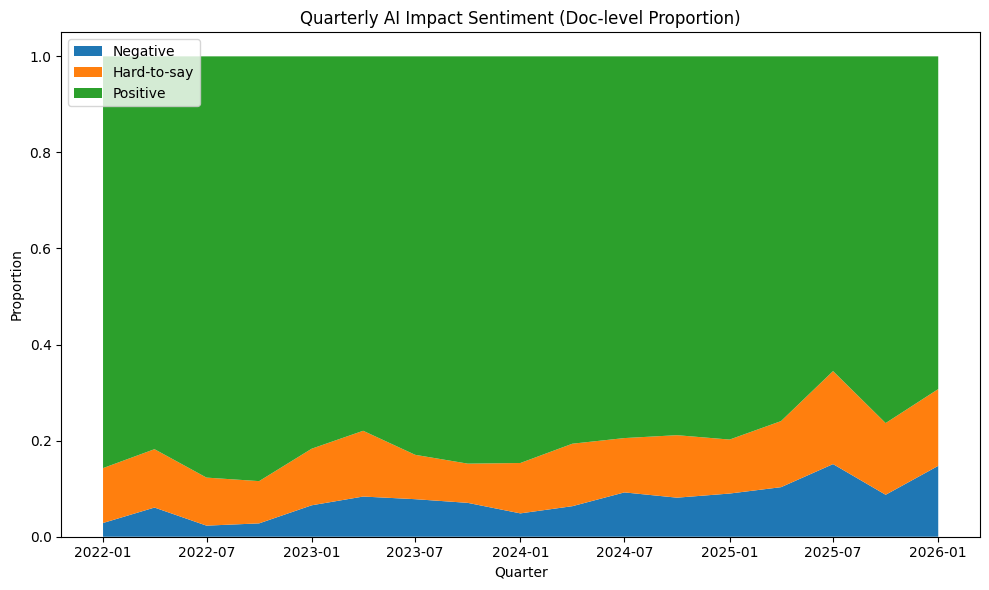

In [76]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
display(quarter_sent_prop)

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()